# Advanced: Add clouds to the simulation

For now, we will manually overwrite the water cloud file in the libradtran input.

In [5]:
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd

config_path = Path('../config/thermal_config.yaml')
import logging
# change to "DEBUG" if you want to see more output
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

N_timesteps = 1

ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2025-04-04T12:00:00', periods=N_timesteps, freq='s'),
        'latitude' : ('time', [51.3406321] * N_timesteps),
        'longitude' : ('time', [12.3747329] * N_timesteps),
        'altitude' : ('altitude', np.arange(0, 10, 0.5)),
    },
    data_vars={
        'surface_temperature' : ('time', np.linspace(300, 350, N_timesteps)),
    }
)


# print("\nSimulation complete!")
# print(f"Dataset variables: {list(ds_sim.data_vars.keys())}")
# print(f"Dataset coordinates: {list(ds_sim.coords.keys())}")
# print(f"Dataset shape: {ds_sim.dims}")

## Water cloud: 

This is how a water cloud looks like in libradtra:
```bash
#      z     LWC    R_eff
#     (km)  (g/m^3) (um)  
      4.000     0    10.0     # The water cloud is located between
      3.000   1.0    10.0     # 2 and 4.0 km. The parameters may 
      2.000   1.0    10.0     # vary with altitude.
```

Let's write it to a file at `work/water_cloud.wc`.


In [6]:
wc_content = """#      z     LWC    R_eff
#     (km)  (g/m^3) (um)
    
    4.000     0    7.0
    3.800   0.5    9.0
    3.500   0.8    10.0
    3.200   1.3    10.0
    3.000   1.7    20.0
    2.800   2.0    17.0
    2.500   1.2    15.0
    2.100   1.0    10.0
    2.000   1.0    10.0
"""

wc_file_path = Path('work/water_cloud.wc')
wc_file_path.parent.mkdir(parents=True, exist_ok=True)
wc_file_path.write_text(wc_content)

print(f"Water cloud definition written to {wc_file_path}")

Water cloud definition written to work/water_cloud.wc


In [7]:
ds_sim = ds.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
    surface_temperature_var='surface_temperature',
    parameter_overrides={
        'wc_file 1D' : 'water_cloud.wc',  # Use the water cloud file
        #'wc_modify tau' : 10 
    }
)


2025-07-22 22:34:53,233 - pyradtran.config - INFO - Loading configuration from: ../config/thermal_config.yaml
2025-07-22 22:34:53,241 - pyradtran.config - INFO - Configuration loaded successfully.


Text(0.5, 1.0, '')

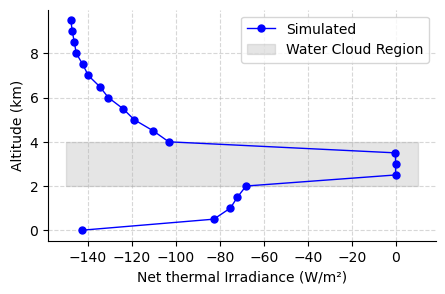

In [10]:
fig, ax = plt.subplots(figsize=(5, 3))

ds_sim.enet.sel(time='2025-04-04T12:00:00').plot(y='altitude', ax=ax, marker='o', color='blue', label='Simulated', lw=1, markersize=5)
# shade the region where the water cloud is present
ax.fill_betweenx(np.arange(2, 5), -150, 10, color='gray', alpha=0.2, label='Water Cloud Region')
ax.set_xlabel('Net thermal Irradiance (W/m²)')
ax.set_ylabel('Altitude (km)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title('')

